In [23]:
from importlib import reload
import simulate_data as sim
reload(sim)
from gwas import gwas_linear, gwas_probit
from scipy.stats import norm
import numpy as np

n, d = 5_000, 200
d_cov = 10
k = 10
corr = 0.7
rho = 0.7
snr_s = 1
snr_y = 1
pi_s = 0.1
pi_y = 0.05
p_sel = 0.3
rng = np.random.default_rng(42)

h2_s_cond = snr_s/(snr_s +1)
h2_s_cov = 0.2
h2_y = snr_y/(snr_y +1)
h2_y_cov = 0.2

# LD matrix
R = sim.simulate_block_correlation_matrix(d, k, corr)
Sigma_W = np.eye(d_cov)

G = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)
W = sim.simulate_design_matrix(n, Sigma_W, intercept = True, rng = rng)

alpha = sim.beta_s(d, R, pi_s, snr_s, rng)
gamma_s = sim.gamma_s(d_cov, Sigma_W, h2_s_cov, rng)

beta, non_genetic_noise_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)
sigma2_y = non_genetic_noise_y - h2_y_cov
gamma_y = sim.gamma_s(d_cov, Sigma_W, h2_y_cov, rng)

s, y, s_star, y_star =  sim.heckman_outcome(G, W, alpha, beta, gamma_s, gamma_y, sigma2_y, p_sel, rho, h2_s_cond, rng)


z_s, b_s_raw = gwas_probit(G, s)[0:2] 
b_s_rescaled = b_s_raw * np.sqrt(1+snr_s) 
b_s = z_s / np.sqrt(len(s)) 
b_y = gwas_linear(G, y)[0] / np.sqrt(s.sum()) # we assume Var(y) = 1 

# correction

In [22]:
from scipy.stats import norm
import numpy as np

# --- Heckman-corrected prediction of marginal outcome effects b_y ---
def predict_b_y(R, alpha, beta, gamma_s, gamma_y, Sigma_W, sigma2_y, rho, p_sel):
    """Return (naive, uncentered, centered) predictions of Cov(G, y* | s=1)."""
    Ra, Rb = R @ alpha, R @ beta

    h2_s = alpha @ Ra                       # Var(G^T alpha)
    V_W = gamma_s @ Sigma_W @ gamma_s       # Var(W^T gamma_s), intercept excluded
    c = np.sqrt(1 - h2_s)
    tau2 = (1 + V_W) / (1 - h2_s)
    q = norm.ppf(p_sel)
    phi_q = norm.pdf(q)
    lam = phi_q / p_sel                     # inverse Mills ratio at q
    psi = q * phi_q / tau2

    kappa = (alpha @ Rb + gamma_s @ Sigma_W @ gamma_y) / c
    K = kappa + rho * np.sqrt(sigma2_y)

    # E[G y* | s=1]  (no centering)
    theta_unc = psi * K / (p_sel * c)
    # Cov(G, y* | s=1)  (centered; matches OLS with intercept)
    theta_cen = K * phi_q * (q + lam) / (tau2 * p_sel * c)

    return Rb, Rb - theta_unc * Ra, Rb - theta_cen * Ra


b_naive, b_pred_unc, b_pred_cen = predict_b_y(
    R, alpha, beta, gamma_s[1:], gamma_y[1:], Sigma_W, sigma2_y, rho, p_sel
)

# --- Comparison against observed GWAS effects (target = b_y) ---
def report(name, pred, target):
    corr = np.corrcoef(pred, target)[0, 1]
    slope = (pred @ target) / (pred @ pred)         # regression through origin
    rmse = np.sqrt(np.mean((pred - target) ** 2))
    print(f"{name:<22} corr={corr:.3f}  slope={slope:.3f}  RMSE={rmse:.4f}")

N_y = int(s.sum())
print(f"N_y = {N_y}, sampling noise sd ~ {1/np.sqrt(N_y):.4f}")
report("naive  R@beta", b_naive, b_y)
report("Heckman (uncentered)", b_pred_unc, b_y)
report("Heckman (centered)", b_pred_cen, b_y)

# Selection-bias component only: b_y - R@beta vs predicted correction
report("bias term (centered)", b_pred_cen - b_naive, b_y - b_naive)

# Oracle check without GWAS noise: empirical covariance among selected samples
sel = s == 1
Gs, ys = G[sel], y_star[sel]
b_emp = (Gs - Gs.mean(0)).T @ (ys - ys.mean()) / N_y
report("naive vs empirical Cov", b_naive, b_emp)
report("Heckman centered vs emp", b_pred_cen, b_emp)

N_y = 30094, sampling noise sd ~ 0.0058
naive  R@beta          corr=0.974  slope=1.078  RMSE=0.0307
Heckman (uncentered)   corr=0.912  slope=0.989  RMSE=0.0519
Heckman (centered)     corr=0.998  slope=1.078  RMSE=0.0114
bias term (centered)   corr=0.927  slope=1.069  RMSE=0.0114
naive vs empirical Cov corr=0.972  slope=1.014  RMSE=0.0285
Heckman centered vs emp corr=0.999  slope=1.016  RMSE=0.0059


# Variance $y^*$ compared to the variance of $y^*\mid s_i =1$

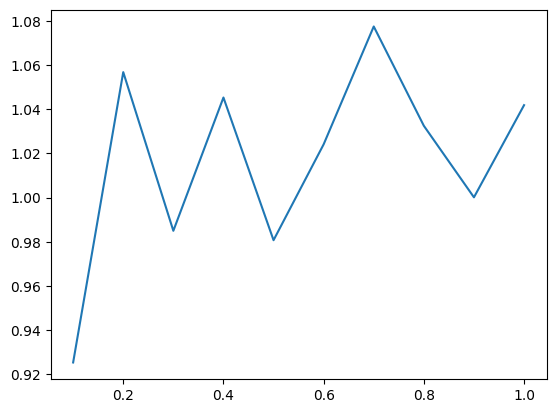

In [29]:
import matplotlib.pyplot as plt

n, d = 10_000, 200
d_cov = 10
k = 10
corr = 0.7
rho = 0.7
snr_s = 2
snr_y = 1
pi_s = 0.1
pi_y = 0.05
p_sel = 0.3
rng = np.random.default_rng(42)

h2_s_cond = snr_s/(snr_s +1)
h2_s_cov = 0.2
h2_y = snr_y/(snr_y +1)
h2_y_cov = 0.2

observed_var = []
p_sel_list = [(i+1)/10 for i in range(10)]


for p_sel in p_sel_list:
    # LD matrix
    R = sim.simulate_block_correlation_matrix(d, k, corr)
    Sigma_W = np.eye(d_cov)
    
    G = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)
    W = sim.simulate_design_matrix(n, Sigma_W, intercept = True, rng = rng)
    
    alpha = sim.beta_s(d, R, pi_s, snr_s, rng)
    gamma_s = sim.gamma_s(d_cov, Sigma_W, h2_s_cov, rng)
    
    beta, non_genetic_noise_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)
    sigma2_y = non_genetic_noise_y - h2_y_cov
    gamma_y = sim.gamma_s(d_cov, Sigma_W, h2_y_cov, rng)
    
    s, y, s_star, y_star =  sim.heckman_outcome(G, W, alpha, beta, gamma_s, gamma_y, sigma2_y, p_sel, rho, h2_s_cond, rng)

    observed_var.append(np.var(y[s==1]))
    
    #print(f"Observed variance: {np.var(y[s==1])}")
    #print(f"Latent variance: {np.var(y_star)}")

plt.plot(p_sel_list, observed_var)

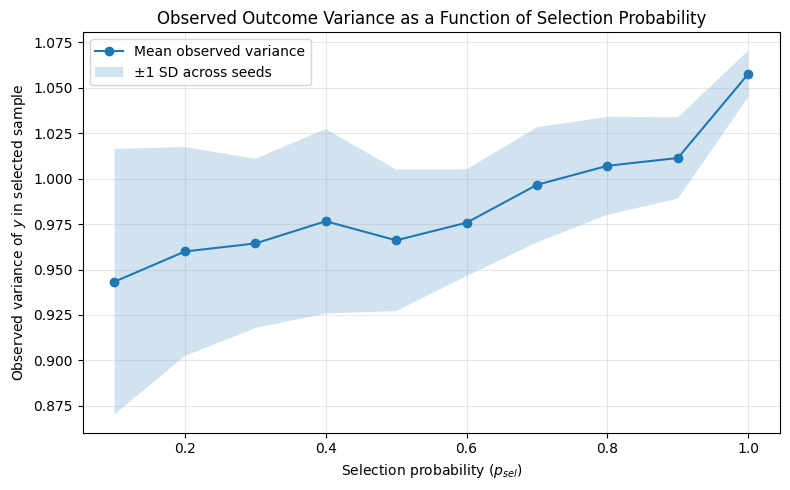

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n, d = 10_000, 200
d_cov = 10
k = 10
corr = 0.7

rho = 0.7
snr_s = 0.5
snr_y = 0.5
pi_s = 0.05
pi_y = 0.05

# Number of independent simulation seeds
n_seeds = 20

# Base seed for reproducibility
base_seed = 42

h2_s_cond = snr_s / (snr_s + 1)
h2_s_cov = 0.2
h2_y = snr_y / (snr_y + 1)
h2_y_cov = 0.2

p_sel_list = [(i + 1) / 10 for i in range(10)]

# Store mean observed variance and standard deviation across seeds
mean_observed_var = []
sd_observed_var = []

for p_sel_current in p_sel_list:

    observed_vars = []

    for seed in range(base_seed, base_seed + n_seeds):
        rng = np.random.default_rng(seed)

        # LD matrix
        R = sim.simulate_block_correlation_matrix(d, k, corr)

        Sigma_W = np.eye(d_cov)

        G = sim.simulate_design_matrix(
            n, R, intercept=False, rng=rng
        )

        W = sim.simulate_design_matrix(
            n, Sigma_W, intercept=True, rng=rng
        )

        alpha = sim.beta_s(
            d, R, pi_s, snr_s, rng
        )

        gamma_s = sim.gamma_s(
            d_cov, Sigma_W, h2_s_cov, rng
        )

        beta, non_genetic_noise_y = sim.beta_heckman(
            d, R, pi_y, snr_y, rng
        )

        sigma2_y = non_genetic_noise_y - h2_y_cov

        gamma_y = sim.gamma_s(
            d_cov, Sigma_W, h2_y_cov, rng
        )

        s, y, s_star, y_star = sim.heckman_outcome(
            G,
            W,
            alpha,
            beta,
            gamma_s,
            gamma_y,
            sigma2_y,
            p_sel_current,
            rho,
            h2_s_cond,
            rng
        )

        # Variance of the observed outcome among selected individuals
        observed_vars.append(
            np.var(y[s == 1])
        )

    # Average across seeds
    mean_observed_var.append(np.mean(observed_vars))
    sd_observed_var.append(np.std(observed_vars, ddof=1))

# Convert to arrays
mean_observed_var = np.asarray(mean_observed_var)
sd_observed_var = np.asarray(sd_observed_var)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    p_sel_list,
    mean_observed_var,
    marker="o",
    label="Mean observed variance"
)

# Optional: ±1 SD across simulation seeds
plt.fill_between(
    p_sel_list,
    mean_observed_var - sd_observed_var,
    mean_observed_var + sd_observed_var,
    alpha=0.2,
    label="±1 SD across seeds"
)

plt.xlabel("Selection probability ($p_{sel}$)")
plt.ylabel("Observed variance of $y$ in selected sample")
plt.title(
    "Observed Outcome Variance as a Function of Selection Probability"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

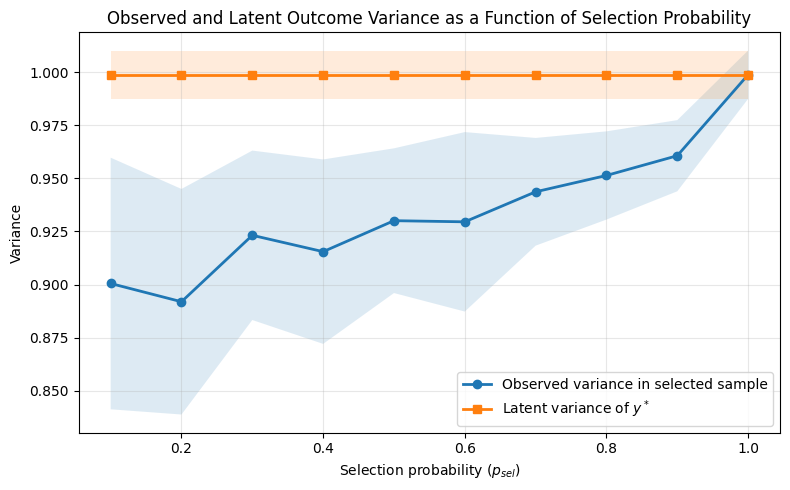

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
reload(sim)

# Simulation parameters
n, d = 10_000, 200
d_cov = 10
k = 10
corr = 0.7

rho = 0.7
snr_s = 0.5
snr_y = 0.5
pi_s = 0.05
pi_y = 0.05

# Number of independent simulation seeds
n_seeds = 20

# Base seed for reproducibility
base_seed = 42

h2_s_cond = snr_s / (snr_s + 1)
h2_s_cov = 0.2
h2_y = snr_y / (snr_y + 1)
h2_y_cov = 0.2

p_sel_list = [(i + 1) / 10 for i in range(10)]

# Store mean and standard deviation of observed variance
mean_observed_var = []
sd_observed_var = []

# Store mean and standard deviation of latent variance
mean_latent_var = []
sd_latent_var = []


for p_sel_current in p_sel_list:

    observed_vars = []
    latent_vars = []

    for seed in range(base_seed, base_seed + n_seeds):

        rng = np.random.default_rng(seed)

        # LD matrix
        R = sim.simulate_block_correlation_matrix(
            d, k, corr
        )

        Sigma_W = np.eye(d_cov)

        # Genotypes
        G = sim.simulate_design_matrix(
            n,
            R,
            intercept=False,
            rng=rng
        )

        # Covariates
        W = sim.simulate_design_matrix(
            n,
            Sigma_W,
            intercept=True,
            rng=rng
        )

        # Selection effects
        alpha = sim.beta_s(
            d,
            R,
            pi_s,
            snr_s,
            rng
        )

        gamma_s = sim.gamma_s(
            d_cov,
            Sigma_W,
            h2_s_cov,
            rng
        )

        # Outcome genetic effects
        beta, non_genetic_noise_y = sim.beta_heckman(
            d,
            R,
            pi_y,
            snr_y,
            rng
        )

        sigma2_y = non_genetic_noise_y - h2_y_cov

        # Outcome covariate effects
        gamma_y = sim.gamma_y(
            d_cov,
            Sigma_W,
            h2_y_cov,
            rng=rng,
            intercept = True
        )

        # Simulate Heckman model
        s, y, s_star, y_star = sim.heckman_outcome(
            G,
            W,
            alpha,
            beta,
            gamma_s,
            gamma_y,
            sigma2_y,
            p_sel_current,
            rho,
            h2_s_cond,
            rng
        )

        # ---------------------------------------------------------
        # 1. Observed variance in the selected sample
        # ---------------------------------------------------------
        observed_vars.append(
            np.var(y[s == 1])
        )

        # ---------------------------------------------------------
        # 2. Latent variance in the full population
        # ---------------------------------------------------------
        latent_vars.append(
            np.var(y_star)
        )

    # -------------------------------------------------------------
    # Average across seeds
    # -------------------------------------------------------------
    mean_observed_var.append(
        np.mean(observed_vars)
    )

    sd_observed_var.append(
        np.std(observed_vars, ddof=1)
    )

    mean_latent_var.append(
        np.mean(latent_vars)
    )

    sd_latent_var.append(
        np.std(latent_vars, ddof=1)
    )


# Convert to arrays
mean_observed_var = np.asarray(mean_observed_var)
sd_observed_var = np.asarray(sd_observed_var)

mean_latent_var = np.asarray(mean_latent_var)
sd_latent_var = np.asarray(sd_latent_var)


# ================================================================
# Plot
# ================================================================

plt.figure(figsize=(8, 5))

# Observed variance among selected individuals
plt.plot(
    p_sel_list,
    mean_observed_var,
    marker="o",
    linewidth=2,
    label="Observed variance in selected sample"
)

# Latent variance in the full population
plt.plot(
    p_sel_list,
    mean_latent_var,
    marker="s",
    linewidth=2,
    label="Latent variance of $y^*$"
)

# Optional: ±1 SD for observed variance
plt.fill_between(
    p_sel_list,
    mean_observed_var - sd_observed_var,
    mean_observed_var + sd_observed_var,
    alpha=0.15
)

# Optional: ±1 SD for latent variance
plt.fill_between(
    p_sel_list,
    mean_latent_var - sd_latent_var,
    mean_latent_var + sd_latent_var,
    alpha=0.15
)

plt.xlabel("Selection probability ($p_{sel}$)")
plt.ylabel("Variance")
plt.title(
    "Observed and Latent Outcome Variance "
    "as a Function of Selection Probability"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()